In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("=== 基于梯度样本选择的增量学习实现 ===")
print("="*80)

print("\n=== 步骤1: 数据加载和预处理 ===")

DATA_DIR = 'minet'

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform_train)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = transform_val

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"数据集大小: {len(dataset)}")
print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"批量大小: {batch_size}")
print(f"类别: {dataset.classes}")
print(f"类别数量: {len(dataset.classes)}")

print("\n=== 步骤1: 数据加载完成 ===")

=== 基于梯度样本选择的增量学习实现 ===

=== 步骤1: 数据加载和预处理 ===
数据集大小: 956
训练集大小: 764
验证集大小: 192
批量大小: 32
类别: ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']
类别数量: 7

=== 步骤1: 数据加载完成 ===


In [2]:
print("\n=== 步骤2: 模型定义 ===")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

num_classes = len(dataset.classes)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)
model.fc.requires_grad = True

model.to(device)

print(f"模型: resnet50")
print(f"类别数量: {num_classes}")

print("\n=== 步骤2: 模型定义完成 ===")




=== 步骤2: 模型定义 ===
使用设备: cuda


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\1/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:07<00:00, 14.0MB/s]


模型: resnet50
类别数量: 7

=== 步骤2: 模型定义完成 ===


In [3]:
print("\n=== 步骤3: 梯度样本选择器定义 ===")

class GradientSampleSelector:
    def __init__(self, buffer_size=100, feature_dim=2048, device='cuda'):
        self.buffer_size = buffer_size
        self.device = device
        self.feature_dim = feature_dim
        
        self.buffer_data = []
        self.buffer_labels = []
        self.buffer_gradients = []
        
        print(f"梯度样本选择器初始化完成")
        print(f"缓冲区大小: {buffer_size}")
        print(f"特征维度: {feature_dim}")
    
    def compute_gradient(self, model, inputs, labels, criterion):
        model.eval()
        inputs, labels = inputs.to(self.device), labels.to(self.device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        gradients = []
        for param in model.parameters():
            if param.requires_grad and param.grad is not None:
                gradients.append(param.grad.flatten())
        
        if gradients:
            gradient_vector = torch.cat(gradients)
        else:
            gradient_vector = torch.zeros(self.feature_dim).to(self.device)
        
        return gradient_vector.detach()
    
    def select_samples(self, model, new_data, new_labels, criterion):
        if len(new_data) == 0:
            return
        
        model.eval()
        
        new_gradients = []
        for i in range(len(new_data)):
            inputs = new_data[i].unsqueeze(0).to(self.device)
            labels = torch.tensor([new_labels[i]]).to(self.device)
            
            grad = self.compute_gradient(model, inputs, labels, criterion)
            new_gradients.append(grad)
        
        new_gradients = torch.stack(new_gradients)
        
        if len(self.buffer_gradients) == 0:
            for i in range(len(new_data)):
                if len(self.buffer_data) < self.buffer_size:
                    self.buffer_data.append(new_data[i])
                    self.buffer_labels.append(new_labels[i])
                    self.buffer_gradients.append(new_gradients[i])
        else:
            existing_gradients = torch.stack(self.buffer_gradients)
            
            similarities = torch.mm(new_gradients, existing_gradients.T)
            
            min_similarities, _ = torch.min(similarities, dim=1)
            
            _, top_indices = torch.topk(min_similarities, k=min(10, len(new_data)))
            
            for idx in top_indices:
                if len(self.buffer_data) < self.buffer_size:
                    self.buffer_data.append(new_data[idx])
                    self.buffer_labels.append(new_labels[idx])
                    self.buffer_gradients.append(new_gradients[idx])
        
        print(f"选择了 {len(self.buffer_data)} 个样本到缓冲区")
    
    def get_buffer(self):
        return self.buffer_data, self.buffer_labels
    
    def clear_buffer(self):
        self.buffer_data = []
        self.buffer_labels = []
        self.buffer_gradients = []
        print("缓冲区已清空")

print("\n=== 步骤3: 梯度样本选择器定义完成 ===")


=== 步骤3: 梯度样本选择器定义 ===

=== 步骤3: 梯度样本选择器定义完成 ===


In [4]:
print("\n=== 步骤4: 在线学习训练 ===")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=0.001, weight_decay=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("优化器: Adam")
print("学习率: 0.001")
print("权重衰减: 0.001")
print("学习率调度: StepLR (每5个epoch衰减10倍)")

selector = GradientSampleSelector(buffer_size=100, feature_dim=2048, device=device)

print("\n=== 步骤4: 在线学习训练开始 ===")

def train_online(model, train_loader, selector, criterion, optimizer, scheduler, 
                 num_epochs=5, sample_interval=20):
    model.train()
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        
        batch_count = 0
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
            
            batch_count += 1
            
            if batch_count % sample_interval == 0:
                for i in range(inputs.size(0)):
                    selector.select_samples(model, inputs[i:i+1], labels[i:i+1], criterion)
        
        scheduler.step()
        
        epoch_loss = running_loss / total
        epoch_acc = running_corrects / total
        
        val_acc = evaluate(model, val_loader)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_acc'].append(val_acc)
        
        print(f"训练损失: {epoch_loss:.4f}, 训练准确率: {epoch_acc*100:.2f}%, 验证准确率: {val_acc*100:.2f}%")
    
    return history

def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

history = train_online(model, train_loader, selector, criterion, optimizer, scheduler,
                       num_epochs=5, sample_interval=10)

print("\n=== 步骤4: 在线学习训练完成 ===")


=== 步骤4: 在线学习训练 ===
优化器: Adam
学习率: 0.001
权重衰减: 0.001
学习率调度: StepLR (每5个epoch衰减10倍)
梯度样本选择器初始化完成
缓冲区大小: 100
特征维度: 2048

=== 步骤4: 在线学习训练开始 ===

Epoch 1/5
------------------------------------------------------------
选择了 1 个样本到缓冲区
选择了 2 个样本到缓冲区
选择了 3 个样本到缓冲区
选择了 4 个样本到缓冲区
选择了 5 个样本到缓冲区
选择了 6 个样本到缓冲区
选择了 7 个样本到缓冲区
选择了 8 个样本到缓冲区
选择了 9 个样本到缓冲区
选择了 10 个样本到缓冲区
选择了 11 个样本到缓冲区
选择了 12 个样本到缓冲区
选择了 13 个样本到缓冲区
选择了 14 个样本到缓冲区
选择了 15 个样本到缓冲区
选择了 16 个样本到缓冲区
选择了 17 个样本到缓冲区
选择了 18 个样本到缓冲区
选择了 19 个样本到缓冲区
选择了 20 个样本到缓冲区
选择了 21 个样本到缓冲区
选择了 22 个样本到缓冲区
选择了 23 个样本到缓冲区
选择了 24 个样本到缓冲区
选择了 25 个样本到缓冲区
选择了 26 个样本到缓冲区
选择了 27 个样本到缓冲区
选择了 28 个样本到缓冲区
选择了 29 个样本到缓冲区
选择了 30 个样本到缓冲区
选择了 31 个样本到缓冲区
选择了 32 个样本到缓冲区
选择了 33 个样本到缓冲区
选择了 34 个样本到缓冲区
选择了 35 个样本到缓冲区
选择了 36 个样本到缓冲区
选择了 37 个样本到缓冲区
选择了 38 个样本到缓冲区
选择了 39 个样本到缓冲区
选择了 40 个样本到缓冲区
选择了 41 个样本到缓冲区
选择了 42 个样本到缓冲区
选择了 43 个样本到缓冲区
选择了 44 个样本到缓冲区
选择了 45 个样本到缓冲区
选择了 46 个样本到缓冲区
选择了 47 个样本到缓冲区
选择了 48 个样本到缓冲区
选择了 49 个样本到缓冲区
选择了 50 个样本到缓冲区
选择了 51 个样本到缓冲区
选择了 52 个样本到缓冲区
选择了 53 个样本到缓冲区


In [6]:
print("\n=== 步骤5: 增量学习模拟 ===")

print("模拟添加新样本进行增量学习...")

buffer_data, buffer_labels = selector.get_buffer()

if len(buffer_data) > 0:
    print(f"从缓冲区加载 {len(buffer_data)} 个样本进行增量学习")
    
    class BufferDataset(Dataset):
        def __init__(self, data, labels, transform=None):
            self.data = data
            self.labels = labels
            self.transform = transform
        
        def __len__(self):
            return len(self.data)
        
        def __getitem__(self, idx):
            img = self.data[idx]
            label = self.labels[idx]
            if isinstance(img, torch.Tensor):
                return img, label
            return img, label
    
    buffer_dataset = BufferDataset(buffer_data, buffer_labels, transform=transform_train)
    buffer_loader = DataLoader(buffer_dataset, batch_size=16, shuffle=True, num_workers=0)
    
    model.train()
    for epoch in range(3):
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in buffer_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
        
        epoch_loss = running_loss / total
        epoch_acc = running_corrects / total
        print(f"增量学习 Epoch {epoch+1}/3: 损失 {epoch_loss:.4f}, 准确率 {epoch_acc*100:.2f}%")
    
    print("增量学习完成")
else:
    print("缓冲区为空，跳过增量学习")

print("\n=== 步骤5: 增量学习模拟完成 ===")


=== 步骤5: 增量学习模拟 ===
模拟添加新样本进行增量学习...
从缓冲区加载 100 个样本进行增量学习
增量学习 Epoch 1/3: 损失 0.5119, 准确率 93.00%
增量学习 Epoch 2/3: 损失 0.4787, 准确率 95.00%
增量学习 Epoch 3/3: 损失 0.4940, 准确率 93.00%
增量学习完成

=== 步骤5: 增量学习模拟完成 ===



=== 步骤6: 模型评估 ===
最终验证准确率: 79.17%

=== 步骤6: 模型评估完成 ===

=== 步骤7: 保存模型 ===
模型已保存: incremental_gss_resnet50.pth

=== 步骤7: 模型保存完成 ===

=== 步骤8: 可视化训练过程 ===
训练曲线已保存: training_history_gss.png

=== 步骤8: 可视化完成 ===


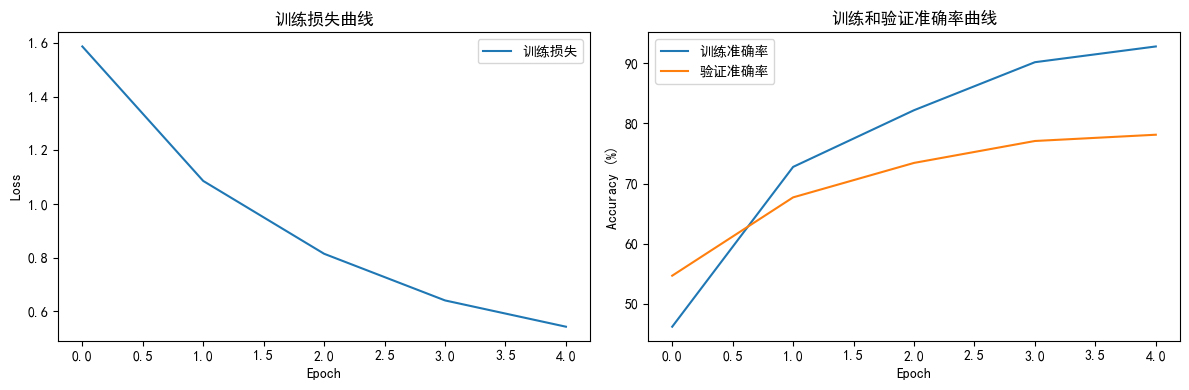

In [8]:
print("\n=== 步骤6: 模型评估 ===")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
final_val_acc = evaluate(model, val_loader)
print(f"最终验证准确率: {final_val_acc*100:.2f}%")

print("\n=== 步骤6: 模型评估完成 ===")

print("\n=== 步骤7: 保存模型 ===")

torch.save(model.state_dict(), 'incremental_gss_resnet50.pth')
print("模型已保存: incremental_gss_resnet50.pth")

print("\n=== 步骤7: 模型保存完成 ===")

print("\n=== 步骤8: 可视化训练过程 ===")

if len(history['train_loss']) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['train_loss'], label='训练损失')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('训练损失曲线')
    ax1.legend()
    
    ax2.plot([acc*100 for acc in history['train_acc']], label='训练准确率')
    ax2.plot([acc*100 for acc in history['val_acc']], label='验证准确率')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('训练和验证准确率曲线')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('training_history_gss.png', dpi=150)
    print("训练曲线已保存: training_history_gss.png")
else:
    print("没有训练历史数据可供可视化")

print("\n=== 步骤8: 可视化完成 ===")
